# M5 forecasting: reproduce, compare, experiment

Train the original Conv1D and XGBoost models, try the improved candidates,
and compare them with the previous-week baseline. All models share the same
training-only product selection, chronological split, and 56 → 7 forecasting task.

From the repository root:
```bash
uv sync --extra cpu --group notebook
uv run --extra cpu --group notebook jupyter lab notebooks/m5_experiments.ipynb
```
In VS Code, select `.venv/bin/python` as the notebook kernel. Download
`sales_train_evaluation.csv`, `calendar.csv`, and `sell_prices.csv` from the
[M5 data page](https://www.kaggle.com/competitions/m5-forecasting-accuracy/data)
into `data/`. Prices are required here for WRMSSE selection.

Run cells in order. The default settings reproduce the documented CPU experiment;
smaller settings are useful for a quick trial. Outputs go into
`artifacts/notebook-01/original/` and `artifacts/notebook-01/improved/`.


## 1. Imports and experiment settings

The notebook uses the same data, model, feature, and scoring modules as the demo.
The original CNN training loop is shown below so you can change its loss or optimizer.


In [1]:
import copy
import json
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xgboost as xgb
from IPython.display import display
from torch import nn
from torch.utils.data import DataLoader

from m5_forecast.adjustment import adjust_totals
from m5_forecast.artifacts import save_artifacts
from m5_forecast.data import CALENDAR_FEATURES, HISTORY, HORIZON, SalesWindows, prepare_data
from m5_forecast.evaluate import backtest, predict, seasonal_baseline
from m5_forecast.improve import train_residual_cnn
from m5_forecast.metrics import WRMSSEScorer, load_revenue, refresh_metrics, rmsse_scale
from m5_forecast.model import DemandCNN
from m5_forecast.train import choose_device
from m5_forecast.xgboost_model import make_features, predict_xgboost, train_xgboost

In [19]:
# Works when Jupyter starts in the repository root or in notebooks/.
ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src/m5_forecast").is_dir() and (path / "pyproject.toml").is_file()
)
DATA_DIR = ROOT / "data"
RUN_DIR = ROOT / "artifacts" / "notebook-01"  # Change the name to keep another experiment.

NUM_SERIES = 100
VAL_DAYS = 56
TEST_DAYS = 56
SEED = 42
THREADS = 4
DEVICE = "cpu"  # "auto" or "cuda" also work for the original CNN.
TRAIN_STRIDE = 7
BATCH_SIZE = 256
CNN_EPOCHS = 15
CNN_LR = 0.001
RESIDUAL_EPOCHS = 20
XGB_ROUNDS = 300
TREE_OBJECTIVES = ["reg:squarederror", "reg:tweedie"]
ADJUSTMENTS = [0, 0.25, 0.5, 0.75, 1]

In [20]:
required = ["sales_train_evaluation.csv", "calendar.csv", "sell_prices.csv"]
missing = [str(DATA_DIR / name) for name in required if not (DATA_DIR / name).is_file()]
if missing:
    raise FileNotFoundError("Download the M5 files first: " + ", ".join(missing))

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(THREADS)
device = choose_device(DEVICE)
print(f"Original CNN: {device}; residual CNN and XGBoost: CPU")
print(f"Experiment directory: {RUN_DIR}")
display(
    pd.Series(
        {
            "Python": platform.python_version(),
            "PyTorch": torch.__version__,
            "XGBoost": xgb.__version__,
            "NumPy": np.__version__,
            "pandas": pd.__version__,
        },
        name="Versions",
    )
)

Original CNN: cpu; residual CNN and XGBoost: CPU
Experiment directory: /home/philippe/Documents/Github/m5-ts-forecast-demo/artifacts/notebook-01


Python        3.12.3
PyTorch    2.8.0+cpu
XGBoost        3.4.1
NumPy          2.5.3
pandas         2.3.3
Name: Versions, dtype: object

## 2. Select products and split time

`prepare_data` ranks series by nonzero-sales fraction, then mean sales, using
**training days only**. Each scale is the training mean, floored at one unit.
Validation and test each use the final 56 days of their respective periods.
Every target window stays within its split; earlier observations supply history.


In [21]:
data = prepare_data(DATA_DIR, NUM_SERIES, VAL_DAYS, TEST_DAYS)
train_origins = data.split.origins("train", TRAIN_STRIDE)
val_origins = data.split.origins("validation")

ranges = [
    ("Training", 0, data.split.train_end, train_origins),
    ("Validation", data.split.train_end, data.split.val_end, val_origins),
    ("Test", data.split.val_end, data.split.total_days, data.split.origins("test")),
]
display(
    pd.DataFrame(
        [
            {
                "Period": name,
                "First day": data.dates[start],
                "Last day": data.dates[end - 1],
                "Forecast dates": len(origins),
            }
            for name, start, end, origins in ranges
        ]
    )
)
train_sales = data.sales[:, : data.split.train_end]
display(
    pd.DataFrame(
        {
            "Series": data.series_ids,
            "Nonzero training fraction": (train_sales > 0).mean(axis=1),
            "Training mean / scale": data.scales,
        }
    ).head()
)
print(f"Sales shape: {data.sales.shape}; calendar features: {CALENDAR_FEATURES}")

,Period,First day,Last day,Forecast dates
0,Training,2011-01-29,2016-01-31,253
1,Validation,2016-02-01,2016-03-27,8
2,Test,2016-03-28,2016-05-22,8


,Series,Nonzero training fraction,Training mean / scale
0,FOODS_3_586_CA_2_evaluation,0.998360,33.092945
1,FOODS_3_252_TX_2_evaluation,0.997813,59.850739
2,FOODS_3_555_TX_2_evaluation,0.997813,51.145981
3,FOODS_3_555_CA_3_evaluation,0.997813,30.969381
4,FOODS_3_586_CA_3_evaluation,0.997266,70.506836


Sales shape: (100, 1941); calendar features: ['weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'event_1', 'event_2', 'snap']


Training windows: 25,300
Past [channels, days]: (8, 56)
Future calendar [days, features]: (7, 7)
Series index: 0; target shape: (7,)


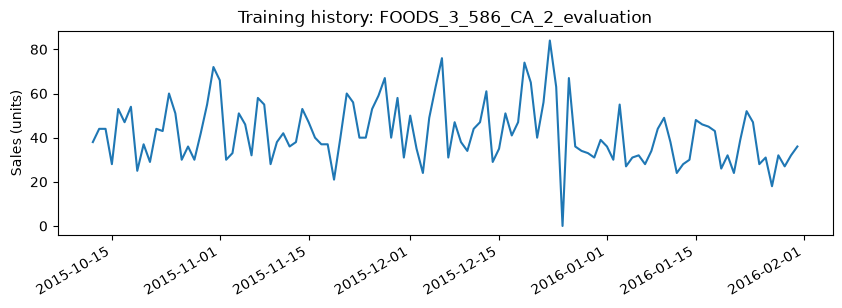

In [22]:
windows = SalesWindows(data, train_origins)
past, calendar, series, target = windows[0]
print(f"Training windows: {len(windows):,}")
print(f"Past [channels, days]: {tuple(past.shape)}")
print(f"Future calendar [days, features]: {tuple(calendar.shape)}")
print(f"Series index: {series.item()}; target shape: {tuple(target.shape)}")

end = data.split.train_end
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(pd.to_datetime(data.dates[end - 112 : end]), data.sales[0, end - 112 : end])
ax.set(title=f"Training history: {data.series_ids[0]}", ylabel="Sales (units)")
fig.autofmt_xdate()
plt.show()

## 3. Baseline and validation metrics

The seasonal baseline repeats the previous seven days. MAE is measured in units/day.
RMSSE scales squared forecast errors by historical daily changes after the first sale.
Demo WRMSSE applies this to 12 aggregation levels with past-28-day revenue weights.
Lower is better; WRMSSE is dimensionless and is not a percentage.

Scales and weights use only observations before each forecast date. This is a
100-series, seven-day metric, not the full M5 leaderboard score.
We defer test evaluation until after candidate selection.


In [23]:
validation_context = load_revenue(data, DATA_DIR, np.r_[train_origins, val_origins])
train_scorer = WRMSSEScorer(data, train_origins, *validation_context)
val_scorer = WRMSSEScorer(data, val_origins, *validation_context)
val_actual = np.stack([data.sales[:, o : o + HORIZON] for o in val_origins], axis=1)


def score_forecasts(forecasts, origins, scorer):
    """Compare forecasts shaped [series, forecast date, horizon] in raw units."""
    actual = np.stack([data.sales[:, o : o + HORIZON] for o in origins], axis=1)
    scales = np.array([[rmsse_scale(sales[:o]) for o in origins] for sales in data.sales])
    rows = []
    for name, forecast in forecasts.items():
        error = forecast - actual
        rows.append(
            {
                "Method": name,
                "MAE": float(np.abs(error).mean()),
                "Mean RMSSE": float(np.sqrt(np.square(error).mean(axis=2) / scales).mean()),
                "Demo WRMSSE": scorer.score(forecast),
            }
        )
    return pd.DataFrame(rows).set_index("Method")


val_forecasts = {"Previous week": seasonal_baseline(data.sales, val_origins)}
display(score_forecasts(val_forecasts, val_origins, val_scorer).round(3))

,MAE,Mean RMSSE,Demo WRMSSE
Method,,,
Previous week,5.996,0.83,0.698


## 4. Original Conv1D: train with MAE

The shared CNN combines normalized sales, calendar features, and a learned
product–store embedding. It predicts all seven days directly.
Training minimizes normalized MAE; checkpoint selection uses validation MAE
in raw units. Edit `loss_fn`, the optimizer, or `DemandCNN` to try another model.


In [24]:
# Reset the seed here so rerunning this training stage is reproducible.
torch.manual_seed(SEED)
original_cnn = DemandCNN(len(data.series_ids)).to(device)
loader = DataLoader(windows, batch_size=BATCH_SIZE, shuffle=True)
optimizer = torch.optim.Adam(original_cnn.parameters(), lr=CNN_LR)
loss_fn = nn.L1Loss()
best_mae, best_epoch, best_weights = float("inf"), 0, None
cnn_history = []
print(original_cnn)

DemandCNN(
  (encoder): Sequential(
    (0): Conv1d(8, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): Conv1d(16, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (embedding): Embedding(100, 8)
  (head): Sequential(
    (0): Linear(in_features=953, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=7, bias=True)
    (3): Softplus(beta=1.0, threshold=20.0)
  )
)


Epoch 01: validation MAE = 5.607
Epoch 02: validation MAE = 5.355
Epoch 03: validation MAE = 5.289
Epoch 04: validation MAE = 5.253
Epoch 05: validation MAE = 5.225
Epoch 06: validation MAE = 5.241
Epoch 07: validation MAE = 5.261
Epoch 08: validation MAE = 5.306
Epoch 09: validation MAE = 5.340
Epoch 10: validation MAE = 5.453
Epoch 11: validation MAE = 5.386
Epoch 12: validation MAE = 5.392
Epoch 13: validation MAE = 5.453
Epoch 14: validation MAE = 5.450
Epoch 15: validation MAE = 5.510
Selected epoch: 5


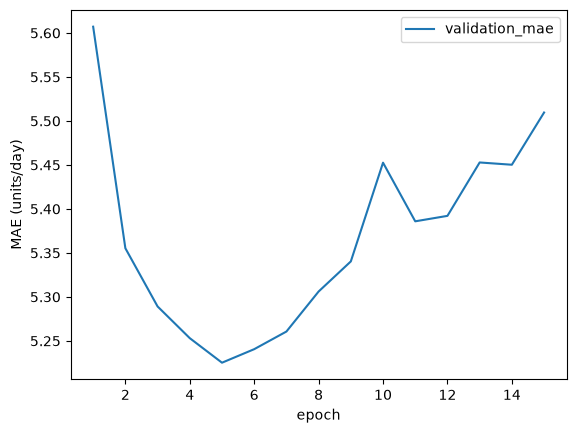

In [25]:
for epoch in range(1, CNN_EPOCHS + 1):
    original_cnn.train()
    total_loss = 0.0
    for past, calendar, series, target in loader:
        optimizer.zero_grad()
        output = original_cnn(past.to(device), calendar.to(device), series.to(device))
        loss = loss_fn(output, target.to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(series)

    forecast = predict(original_cnn, data, val_origins, device)
    val_mae = float(np.abs(forecast - val_actual).mean())
    if val_mae < best_mae:
        best_mae, best_epoch = val_mae, epoch
        best_weights = copy.deepcopy(original_cnn.state_dict())
    cnn_history.append(
        {
            "epoch": epoch,
            "train_scaled_mae": total_loss / len(windows),
            "validation_mae": val_mae,
        }
    )
    print(f"Epoch {epoch:02d}: validation MAE = {val_mae:.3f}")

original_cnn.load_state_dict(best_weights)
cnn_details = {"best_epoch": best_epoch, "best_validation_mae": best_mae}
val_forecasts["Original Conv1D"] = predict(original_cnn, data, val_origins, device)
print(f"Selected epoch: {best_epoch}")
pd.DataFrame(cnn_history).plot(x="epoch", y="validation_mae", ylabel="MAE (units/day)")
plt.show()

## 5. Original XGBoost

Each row represents a series, forecast date, and horizon day. Features include
56 normalized sales lags, one-hot series identity, horizon day, and known calendar
features. Targets are normalized sales; predictions are restored to raw units.
Validation MAE selects the best boosting round, with 20-round patience.


In [26]:
sample_features = make_features(data, train_origins[:1], series_indices=[0])
print(f"One forecast's features: {sample_features.shape}")
original_trees, original_tree_config = train_xgboost(
    data,
    stride=TRAIN_STRIDE,
    rounds=XGB_ROUNDS,
    threads=THREADS,
    seed=SEED,
)
val_forecasts["Original XGBoost"] = predict_xgboost(original_trees, data, val_origins)
display(pd.Series(original_tree_config))
display(score_forecasts(val_forecasts, val_origins, val_scorer).round(3))

One forecast's features: (7, 164)


rounds                                                               300
best_round                                                            85
best_validation_mae                                             5.119704
train_stride                                                           7
threads                                                                4
seed                                                                  42
parameters             {'objective': 'reg:squarederror', 'tree_method...
enhanced                                                           False
selection_metric                                                     mae
dtype: object

,MAE,Mean RMSSE,Demo WRMSSE
Method,,,
Previous week,5.996,0.830,0.698
Original Conv1D,5.225,0.707,0.765
Original XGBoost,5.120,0.691,0.706


## 6. Improved CNN: seasonal residuals and hierarchical loss

Start with the mean of four matching weekdays and learn positive multiplicative
corrections. `train_residual_cnn` uses batches containing every selected series
at the same forecast dates, so its loss includes store/category/total errors.
Validation WRMSSE selects the checkpoint. This helper runs on CPU, with learning
rate 0.0005; its readable loop lives in `src/m5_forecast/improve.py`.


Residual CNN epoch 01: validation WRMSSE=0.6173
Residual CNN epoch 02: validation WRMSSE=0.6260
Residual CNN epoch 03: validation WRMSSE=0.6182
Residual CNN epoch 04: validation WRMSSE=0.6276
Residual CNN epoch 05: validation WRMSSE=0.6322
Residual CNN epoch 06: validation WRMSSE=0.6322
Residual CNN epoch 07: validation WRMSSE=0.6304
Residual CNN epoch 08: validation WRMSSE=0.5982
Residual CNN epoch 09: validation WRMSSE=0.6025
Residual CNN epoch 10: validation WRMSSE=0.5987
Residual CNN epoch 11: validation WRMSSE=0.5962
Residual CNN epoch 12: validation WRMSSE=0.5788
Residual CNN epoch 13: validation WRMSSE=0.5928
Residual CNN epoch 14: validation WRMSSE=0.5840
Residual CNN epoch 15: validation WRMSSE=0.5917
Residual CNN epoch 16: validation WRMSSE=0.5862
Residual CNN epoch 17: validation WRMSSE=0.5757
Residual CNN epoch 18: validation WRMSSE=0.5642
Residual CNN epoch 19: validation WRMSSE=0.5858
Residual CNN epoch 20: validation WRMSSE=0.5955


best_epoch                18.00000
best_validation_wrmsse     0.56422
dtype: float64

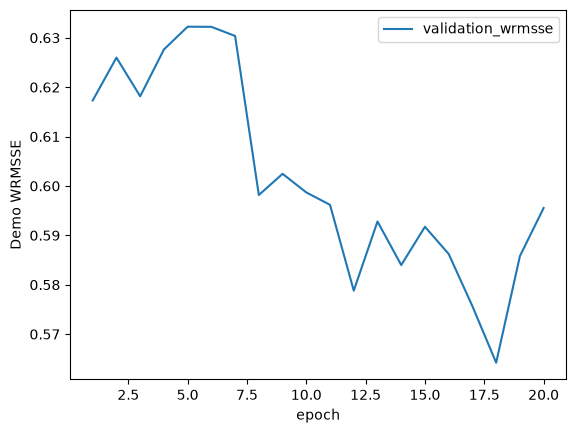

In [27]:
residual_cnn, residual_details, residual_history = train_residual_cnn(
    data,
    train_origins,
    train_scorer,
    val_origins,
    val_scorer,
    epochs=RESIDUAL_EPOCHS,
    threads=THREADS,
    seed=SEED,
)
val_forecasts["Residual Conv1D"] = predict(residual_cnn, data, val_origins, torch.device("cpu"))
display(pd.Series(residual_details))
pd.DataFrame(residual_history).plot(x="epoch", y="validation_wrmsse", ylabel="Demo WRMSSE")
plt.show()

## 7. Improved XGBoost: demand summaries and Tweedie loss

Enhanced features add rolling means, standard deviations, and zero fractions
over 7/14/28/56 days, the training sales scale, and matching-weekday lags.
Every sales feature ends before the forecast date, including later horizon days.
Compare squared error with Tweedie loss; both select rounds by validation WRMSSE.
Change `TREE_OBJECTIVES` or the feature builder for further experiments.


In [28]:
enhanced_features = make_features(data, train_origins[:1], [0], enhanced=True)
print(f"Enhanced feature shape: {enhanced_features.shape}")
cnn_candidates = {"Original Conv1D": original_cnn, "Residual Conv1D": residual_cnn}
tree_candidates = {"Original XGBoost": original_trees}
tree_configs = {"Original XGBoost": original_tree_config}

for objective in TREE_OBJECTIVES:
    name = f"Enhanced XGBoost ({objective})"
    trees, details = train_xgboost(
        data,
        stride=TRAIN_STRIDE,
        rounds=XGB_ROUNDS,
        threads=THREADS,
        seed=SEED,
        enhanced=True,
        objective=objective,
        scorer=val_scorer,
    )
    tree_candidates[name] = trees
    tree_configs[name] = details
    val_forecasts[name] = predict_xgboost(trees, data, val_origins)
    print(f"{name}: selected round {details['best_round']}")

display(score_forecasts(val_forecasts, val_origins, val_scorer).round(3))

Enhanced feature shape: (7, 180)
Enhanced XGBoost (reg:squarederror): selected round 31
Enhanced XGBoost (reg:tweedie): selected round 33


,MAE,Mean RMSSE,Demo WRMSSE
Method,,,
Previous week,5.996,0.830,0.698
Original Conv1D,5.225,0.707,0.765
Original XGBoost,5.120,0.691,0.706
Residual Conv1D,4.946,0.685,0.564
Enhanced XGBoost (reg:squarederror),4.851,0.662,0.597
Enhanced XGBoost (reg:tweedie),4.825,0.660,0.590


## 8. Select models and daily-total adjustments on validation

`alpha=0` keeps the raw forecast. `alpha=1` makes each daily total match last
week's total while retaining predicted product shares. Intermediate values blend
the totals. This is not a per-product blend with the baseline.
Try the declared `ADJUSTMENTS` for each candidate, then freeze one CNN and one
tree model. Copies preserve the original models for the final comparison.


In [29]:
validation_rows = []
for name in [*cnn_candidates, *tree_candidates]:
    forecast = val_forecasts[name]
    for alpha in ADJUSTMENTS:
        adjusted = adjust_totals(forecast, data, val_origins, alpha)
        validation_rows.append(
            {
                "Method": name,
                "Alpha": alpha,
                "Validation WRMSSE": val_scorer.score(adjusted),
            }
        )
validation_results = pd.DataFrame(validation_rows)
display(validation_results.sort_values("Validation WRMSSE", kind="stable").round(4))


def best_candidate(names):
    candidates = validation_results[validation_results.Method.isin(names)]
    return candidates.loc[candidates["Validation WRMSSE"].idxmin()]


cnn_choice = best_candidate(cnn_candidates)
tree_choice = best_candidate(tree_candidates)
selected_cnn = copy.deepcopy(cnn_candidates[cnn_choice.Method]).to(device)
selected_cnn.reconcile_alpha = float(cnn_choice.Alpha)
selected_trees = copy.deepcopy(tree_candidates[tree_choice.Method])
selected_trees.set_attr(reconcile_alpha=str(float(tree_choice.Alpha)))
display(pd.DataFrame([cnn_choice, tree_choice]).reset_index(drop=True))

,Method,Alpha,Validation WRMSSE
6,Residual Conv1D,0.25,0.5543
5,Residual Conv1D,0.00,0.5642
7,Residual Conv1D,0.50,0.5663
21,Enhanced XGBoost (reg:tweedie),0.25,0.5672
22,Enhanced XGBoost (reg:tweedie),0.50,0.5694
17,Enhanced XGBoost (reg:squarederror),0.50,0.5702
16,Enhanced XGBoost (reg:squarederror),0.25,0.5706
20,Enhanced XGBoost (reg:tweedie),0.00,0.5902
3,Original Conv1D,0.75,0.5930
18,Enhanced XGBoost (reg:squarederror),0.75,0.5962


,Method,Alpha,Validation WRMSSE
0,Residual Conv1D,0.25,0.554300
1,Enhanced XGBoost (reg:tweedie),0.25,0.567221


## 9. Freeze choices, then evaluate test dates

Compare the baseline, the original models, and the selected models across every
test forecast date. Later forecasts may use sales already observed before their
date; weights and model preprocessing stay fixed. No models are refitted on test.

The documented CPU run reached original MAE **4.935 / 5.051** and WRMSSE
**0.653 / 0.664** for CNN / XGBoost. After improvements, MAE was **4.810 / 4.650**
and WRMSSE **0.486 / 0.490**; baseline MAE **5.917**, WRMSSE **0.618**.
Different settings, hardware, or package versions can change these values.
Use validation for new experiments; a fresh holdout is stronger evidence once
these test results have informed development.


In [30]:
test_origins = data.split.origins("test")
test_context = load_revenue(data, DATA_DIR, test_origins)
test_scorer = WRMSSEScorer(data, test_origins, *test_context)
test_forecasts = {
    "Previous week": seasonal_baseline(data.sales, test_origins),
    "Original Conv1D": predict(original_cnn, data, test_origins, device),
    "Original XGBoost": predict_xgboost(original_trees, data, test_origins),
    "Selected Conv1D": predict(selected_cnn, data, test_origins, device),
    "Selected XGBoost": predict_xgboost(selected_trees, data, test_origins),
}
test_results = score_forecasts(test_forecasts, test_origins, test_scorer)
print(f"{len(data.series_ids)} series × {len(test_origins)} dates × {HORIZON} days")
display(test_results.round(3))

100 series × 8 dates × 7 days


,MAE,Mean RMSSE,Demo WRMSSE
Method,,,
Previous week,5.917,0.842,0.618
Original Conv1D,4.935,0.675,0.653
Original XGBoost,5.051,0.683,0.664
Selected Conv1D,4.810,0.673,0.486
Selected XGBoost,4.650,0.643,0.490


In [31]:
date_results = []
for date_index, origin in enumerate(test_origins):
    origins = np.asarray([origin])
    scorer = WRMSSEScorer(data, origins, *test_context)
    forecasts = {
        name: values[:, date_index : date_index + 1] for name, values in test_forecasts.items()
    }
    scores = score_forecasts(forecasts, origins, scorer).reset_index()
    scores.insert(0, "Forecast date", data.dates[origin])
    date_results.append(scores)
results_by_date = pd.concat(date_results, ignore_index=True)
display(
    results_by_date.pivot(index="Forecast date", columns="Method", values="Demo WRMSSE").round(3)
)

Method,Original Conv1D,Original XGBoost,Previous week,Selected Conv1D,Selected XGBoost
Forecast date,,,,,
2016-03-28,0.667,0.761,0.658,0.500,0.532
2016-04-04,0.565,0.544,0.641,0.471,0.362
2016-04-11,0.739,0.805,0.637,0.526,0.617
2016-04-18,0.570,0.562,0.620,0.549,0.442
2016-04-25,0.620,0.672,0.590,0.432,0.511
2016-05-02,0.694,0.686,0.673,0.467,0.504
2016-05-09,0.594,0.594,0.593,0.419,0.419
2016-05-16,0.773,0.691,0.533,0.521,0.535


## 10. Inspect one forecast

Change `series_index` and `date_index`. The chart shows selected models; the
daily table also includes the originals. Scores for one series can differ from
the overall comparison above.


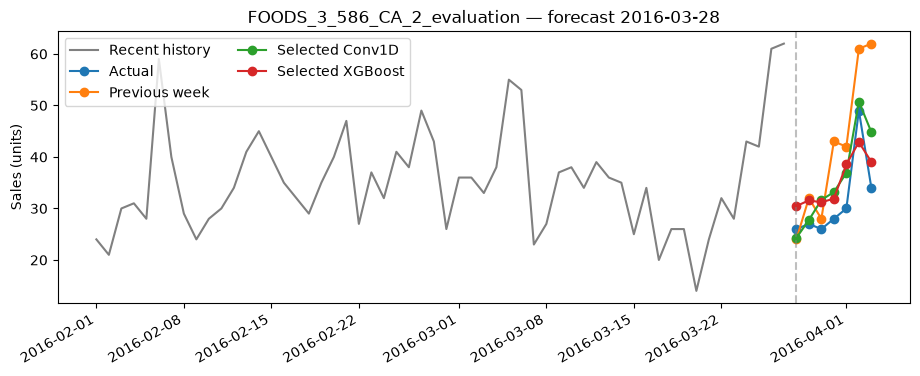

,Actual,Previous week,Original Conv1D,Original XGBoost,Selected Conv1D,Selected XGBoost
2016-03-28,26.0,24.0,36.610001,36.689999,24.270000,30.469999
2016-03-29,27.0,32.0,29.059999,34.130001,27.760000,31.559999
2016-03-30,26.0,28.0,29.200001,34.009998,31.639999,31.190001
2016-03-31,28.0,43.0,30.340000,34.500000,33.180000,31.910000
2016-04-01,30.0,42.0,34.360001,37.279999,36.900002,38.540001
2016-04-02,49.0,61.0,37.040001,37.279999,50.750000,42.889999
2016-04-03,34.0,62.0,40.150002,37.250000,44.820000,39.029999


Previous week       10.857142
Original Conv1D      5.812707
Original XGBoost     7.795745
Selected Conv1D      4.682605
Selected XGBoost     5.403310
Name: This forecast's MAE, dtype: float32

In [32]:
series_index = 0
date_index = 0
origin = int(test_origins[date_index])
dates = pd.to_datetime(data.dates[origin : origin + HORIZON])
actual = data.sales[series_index, origin : origin + HORIZON]
daily = pd.DataFrame(
    {
        "Actual": actual,
        **{name: values[series_index, date_index] for name, values in test_forecasts.items()},
    },
    index=dates,
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(
    pd.to_datetime(data.dates[origin - HISTORY : origin]),
    data.sales[series_index, origin - HISTORY : origin],
    label="Recent history",
    color="gray",
)
for name in ["Actual", "Previous week", "Selected Conv1D", "Selected XGBoost"]:
    ax.plot(dates, daily[name], marker="o", label=name)
ax.axvline(dates[0], color="gray", linestyle="--", alpha=0.5)
ax.set(
    title=f"{data.series_ids[series_index]} — forecast {data.dates[origin]}", ylabel="Sales (units)"
)
ax.legend(ncol=2)
fig.autofmt_xdate()
plt.show()
display(daily.round(2))
display(
    daily.drop(columns="Actual")
    .sub(daily.Actual, axis=0)
    .abs()
    .mean()
    .rename("This forecast's MAE")
)

## 11. Save both runs for the dashboard

Save CPU-portable weights, preprocessing, tree settings, forecast tables, and
all metric reports. `metrics.json` is recomputed with the same scoring code used
by the CLI. Rerunning this cell replaces this experiment's saved files.


In [33]:
run_config = {
    "data_dir": str(DATA_DIR),
    "num_series": NUM_SERIES,
    "val_days": VAL_DAYS,
    "test_days": TEST_DAYS,
    "seed": SEED,
    "train_stride": TRAIN_STRIDE,
    "batch_size": BATCH_SIZE,
    "epochs": CNN_EPOCHS,
    "lr": CNN_LR,
    "threads": THREADS,
    "device": DEVICE,
    "resolved_device": str(device),
    **cnn_details,
}


def save_run(directory, model, trees, config, tree_config, history):
    """Write a complete run that Streamlit can open without training."""
    forecasts, _, metrics = backtest(
        model,
        data,
        test_origins,
        device,
        predict_xgboost(trees, data, test_origins),
    )
    config = {**config, "artifacts_dir": str(directory)}
    save_artifacts(directory, model, data, config, metrics)
    trees.save_model(directory / "xgboost.json")
    (directory / "xgboost_config.json").write_text(json.dumps(tree_config, indent=2) + "\n")
    (directory / "training_history.json").write_text(json.dumps(history, indent=2) + "\n")
    forecasts.to_csv(directory / "test_forecasts.csv", index=False)
    return refresh_metrics(directory, data, DATA_DIR)

In [34]:
original_metrics = save_run(
    RUN_DIR / "original",
    original_cnn,
    original_trees,
    run_config,
    original_tree_config,
    cnn_history,
)
improved_config = {
    **run_config,
    "selection_metric": "validation_wrmsse",
    "selected_cnn": cnn_choice.Method,
    "selected_xgboost": tree_choice.Method,
    "adjusted_validation_wrmsse": float(cnn_choice["Validation WRMSSE"]),
}
if cnn_choice.Method == "Residual Conv1D":
    improved_config.update(
        **residual_details,
        epochs=RESIDUAL_EPOCHS,
        lr=0.0005,
        training_loss="hierarchical_wrmsse",
    )
    improved_config.pop("best_validation_mae", None)
selected_tree_config = {
    **tree_configs[tree_choice.Method],
    "reconcile_alpha": float(tree_choice.Alpha),
    "adjusted_validation_wrmsse": float(tree_choice["Validation WRMSSE"]),
}
improved_metrics = save_run(
    RUN_DIR / "improved",
    selected_cnn,
    selected_trees,
    improved_config,
    selected_tree_config,
    residual_history if cnn_choice.Method == "Residual Conv1D" else cnn_history,
)

In [35]:
validation_results.to_csv(RUN_DIR / "validation_candidates.csv", index=False)
test_results.to_csv(RUN_DIR / "comparison.csv")
results_by_date.to_csv(RUN_DIR / "comparison_by_date.csv", index=False)
(RUN_DIR / "improved" / "residual_training_history.json").write_text(
    json.dumps(residual_history, indent=2) + "\n"
)
report = {
    "selection_metric": "validation_wrmsse",
    "selected_cnn": cnn_choice.Method,
    "selected_xgboost": tree_choice.Method,
    "cnn_validation_wrmsse": float(cnn_choice["Validation WRMSSE"]),
    "xgboost_validation_wrmsse": float(tree_choice["Validation WRMSSE"]),
    "validation_candidates": validation_results.to_dict(orient="records"),
    "before_test_metrics": original_metrics,
    "after_test_metrics": improved_metrics,
    "settings": {
        "epochs": RESIDUAL_EPOCHS,
        "xgb_rounds": XGB_ROUNDS,
        "threads": THREADS,
        "seed": SEED,
        "adjustments": ADJUSTMENTS,
    },
}
(RUN_DIR / "improved" / "improvement_results.json").write_text(json.dumps(report, indent=2) + "\n")
print(f"Saved original and improved runs under {RUN_DIR}")
print(f"M5_ARTIFACTS_DIR={RUN_DIR / 'improved'} uv run --extra cpu streamlit run app.py")

Saved original and improved runs under /home/philippe/Documents/Github/m5-ts-forecast-demo/artifacts/notebook-01
M5_ARTIFACTS_DIR=/home/philippe/Documents/Github/m5-ts-forecast-demo/artifacts/notebook-01/improved uv run --extra cpu streamlit run app.py


## 12. Try another experiment

- Set a new `RUN_DIR`, change one setting, and restart the kernel before running all cells.
- Try another CNN loss or architecture in step 4. Residual training is in `improve.py`.
- Add sales features in `xgboost_model.make_features`, or adjust tree parameters in
  `train_xgboost`. Change `TREE_OBJECTIVES` and `ADJUSTMENTS` here.
- Add a candidate to the dictionaries before step 8; choose using validation scores.
- Changing series selection, history, or split requires rebuilding all downstream
  windows, features, scorers, and models. The 56-day history and seven-day horizon
  are defined in `data.py`; saved artifacts must match those definitions.

After editing imported Python modules, restart the kernel to use the new code.
Keep test data out of tuning. Adding sparse-selling products can reveal undefined
RMSSE/WRMSSE scales for constant histories; investigate those rather than hiding them.
Read the [evaluation guide](../docs/operations/evaluation.md) and
[improvement notes](../docs/operations/improvements.md) for metric details and limitations.
